In [1]:
from modules import Embedder, Decoder
from dataset import LOBSTERLevel10Dataset
from torch.nn.modules.loss import MSELoss
from torch.utils.data import DataLoader
from torch import optim
from itertools import chain
import torch

LATENT_DIMS = 64
EPOCHS = 15

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

embedder = Embedder.to(device)
decoder = Decoder.to(device)

train_data = LOBSTERLevel10Dataset(train=True)
train_loader = DataLoader(train_data, shuffle=True, batch_size=1024)

optimizer = optim.Adam(chain(embedder.parameters(), decoder.parameters()), lr=3e-4)
loss = MSELoss()

In [2]:
for epoch in range(EPOCHS):
    # TODO
    # z = torch.zeros(...)
    # then inside the loop, do one round of embeddings, then shift this vector forward and run embeddings again
    # actually I don't think this can be batched????
    total_loss = 0
    for datum in train_loader:
        datum = datum.to(device)
        optimizer.zero_grad()
        z = embedder(datum)
        recon = decoder(z)
        recon_loss = loss(datum, recon)
        recon_loss.backward()
        optimizer.step()
        total_loss += recon_loss.item()
    print(f'Epoch {epoch+1} done, total reconstruction loss = {total_loss:1.7f}')

Epoch 1 done, total reconstruction loss = 21.2119560
Epoch 2 done, total reconstruction loss = 0.0106995
Epoch 3 done, total reconstruction loss = 0.0032099
Epoch 4 done, total reconstruction loss = 0.0012200
Epoch 5 done, total reconstruction loss = 0.0006317
Epoch 6 done, total reconstruction loss = 0.0003908
Epoch 7 done, total reconstruction loss = 0.0002598
Epoch 8 done, total reconstruction loss = 0.0001810
Epoch 9 done, total reconstruction loss = 0.0001324
Epoch 10 done, total reconstruction loss = 0.0001016
Epoch 11 done, total reconstruction loss = 0.0000810
Epoch 12 done, total reconstruction loss = 0.0000659
Epoch 13 done, total reconstruction loss = 0.0000540
Epoch 14 done, total reconstruction loss = 0.0000442
Epoch 15 done, total reconstruction loss = 0.0000366


Mean absolute difference (prediction vs. actual) = $0.00037


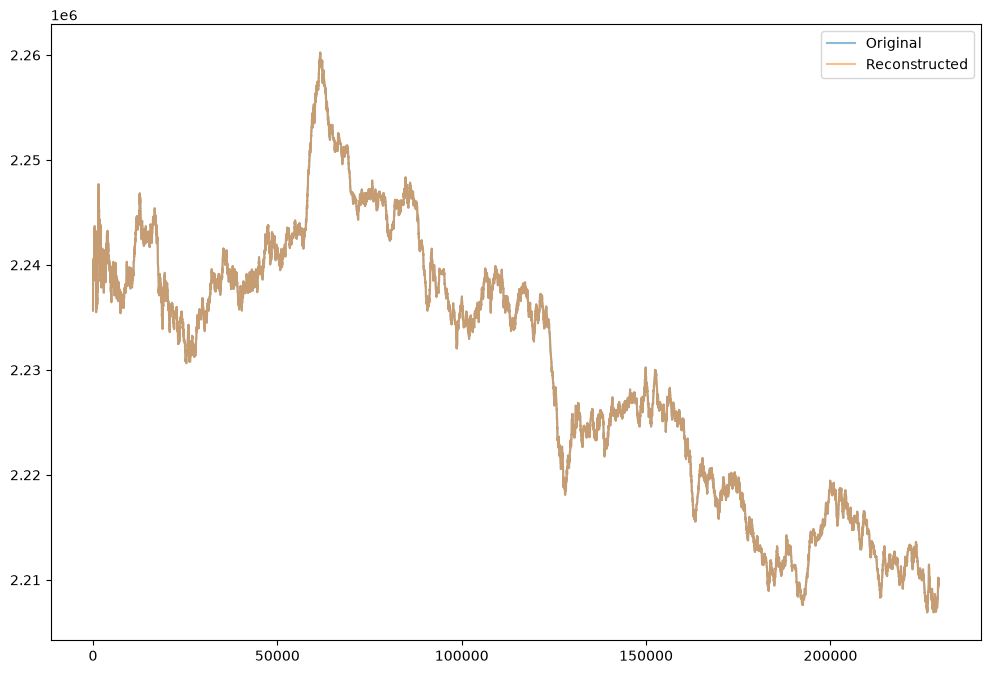

In [3]:
from dataset import load_dfs
import matplotlib.pyplot as plt
import numpy as np

books, _ = load_dfs()

midpoints = np.array(0.5 * (books['ASKp1'] + books['BIDp1']))

midpoints_recon = []

for batch in DataLoader(train_data, shuffle=False, batch_size=1024):
    batch = batch.to(device)
    with torch.no_grad():
        batch_recon = decoder(embedder(batch))
    midpoints_recon.extend((train_data.LOG_MIDPOINT_STD * batch_recon.squeeze() + train_data.LOG_MIDPOINT_MEAN).exp().tolist())

midpoints_recon = np.array(midpoints_recon)
midpoints = midpoints[:len(midpoints_recon)]

plt.figure(figsize=(12, 8))

plt.plot(midpoints, label='Original', alpha=0.5)
plt.plot(midpoints_recon, label='Reconstructed', alpha=0.5)
plt.legend()

print(f'Mean absolute difference (prediction vs. actual) = ${np.mean(np.absolute(midpoints - midpoints_recon)) / 10000:.5f}')